In [ ]:
import os
from glob import glob

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random
from tqdm import tqdm
import cv2
from PIL import Image
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, 
    precision_score, recall_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

import torch
from torch import optim, nn
import torch.nn.functional as F 
from torchvision import transforms as T, models
from torch.utils.data import Dataset, DataLoader, random_split
from torch.amp import autocast, GradScaler  

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# CUDA optimizations
torch.backends.cudnn.benchmark = True  # Auto-tune for faster convolutions
torch.backends.cudnn.deterministic = False  # Allow non-deterministic for speed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PATH = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'

### Load data

In [ ]:
all_image_paths = {
    os.path.basename(p): p for p in glob(f'{PATH}/images_*/images/*.png')
}
print('Images found:', len(all_image_paths))

labels = pd.read_csv(f'{PATH}/Data_Entry_2017.csv')
labels.rename(columns={'Follow-up #' : 'follow_up', 'OriginalImage[Width': 'OriginalImageWidth', 'Height]': 'OriginalImageHeight', 'OriginalImagePixelSpacing[x': 'OriginalImagePixelSpacing_x', 'y]': 'OriginalImagePixelSpacing_y'}, inplace=True)
labels.columns = [
    re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', col).capitalize().replace(' ', '_')
    for col in labels.columns
]
labels = labels[['Image_index', 'Finding_labels', 'Follow_up', 'Patient_id', 'Patient_age', 'Patient_gender', 'View_position']]

labels.loc[labels['Patient_age'] > 100, 'Patient_age'] = np.nan #Min: 148, Max: 414 yrs old
labels['Patient_age'] = labels.groupby('Patient_id')['Patient_age'].ffill().bfill()

label_cols = labels['Finding_labels'].str.get_dummies(sep='|')
labels = pd.concat([labels, label_cols], axis=1)
labels['Finding_labels'] = np.where(labels['Finding_labels'] == 'No Finding', 0, 1)
# labels.drop(columns=['Finding_labels'], inplace=True)
labels.rename(columns={'No Finding': 'No_Finding'}, inplace=True)
labels.sort_values(by=['Patient_id', 'Follow_up'], inplace=True)
labels.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [ ]:
# Random split
# patient_ids = labels['Patient_id'].unique()
# np.random.shuffle(patient_ids)

# n_train = int(len(patient_ids) * 0.8)
# train_patients = patient_ids[: n_train]
# test_patients = patient_ids[n_train :]

# train_labels = labels[labels['Patient_id'].isin(train_patients)].reset_index(drop=True)
# test_labels = labels[labels['Patient_id'].isin(test_patients)].reset_index(drop=True)

with open(f'{PATH}/train_val_list.txt', 'r') as file:
    train_list = file.read().split('\n')

with open(f'{PATH}/test_list.txt', 'r') as file:
    test_list = file.read().split('\n')

train_labels = labels.loc[labels['Image_index'].isin(train_list)].copy()
test_labels = labels.loc[labels['Image_index'].isin(test_list)].copy()

print(f'Train shape: {train_labels.shape}')
print(f'Test shape: {test_labels.shape}')
assert set(train_labels['Patient_id']).isdisjoint(test_labels['Patient_id'])

In [ ]:
# Basic dataset information
print('=== Basic Dataset Information ===')
print(f'Total number of images: {len(labels)}')
print(f'Total number of unique patients: {labels['Patient_id'].nunique()}')
print(f'Dataset shape: {labels.shape}')

print('\n=== Train Set Information ===')
print(f'Number of images (train): {len(train_labels)}')
print(f'Number of unique patients (train): {train_labels['Patient_id'].nunique()}')
print(f'Train set shape: {train_labels.shape}')

print('\n=== Test Set Information ===')
print(f'Number of images (test): {len(test_labels)}')
print(f'Number of unique patients (test): {test_labels['Patient_id'].nunique()}')
print(f'Test set shape: {test_labels.shape}')

In [ ]:
disease_cols = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# Class distributions
disease_counts_train = train_labels[disease_cols].sum().sort_values(ascending=False)
disease_counts_include_nf_train = train_labels[disease_cols + ['No_Finding']].sum().sort_values(ascending=False)
disease_counts_test = test_labels[disease_cols].sum().sort_values(ascending=False)
disease_counts_include_nf_test = test_labels[disease_cols + ['No_Finding']].sum().sort_values(ascending=False)

# Percentage of disease labels on train data
disease_pct = (disease_counts_include_nf_train / len(train_labels) * 100).round(2)
print(f'\nDisease prevalence (%):\n{disease_pct}')

# Percentage of disease labels on test data
disease_pct = (disease_counts_include_nf_test / len(test_labels) * 100).round(2)
print(f'\nDisease prevalence (%):\n{disease_pct}')

In [22]:
# def create_balanced_subset(df, disease_cols, samples_per_class=100, min_total=2000):
#     selected_indices = set()
    
#     for col in disease_cols:
#         positive_indices = df[df[col] == 1].index.tolist()
#         n_select = min(samples_per_class, len(positive_indices))
#         selected_indices.update(np.random.choice(positive_indices, n_select, replace=False))
    
#     remaining_indices = list(set(df.index) - selected_indices)
#     n_remaining = max(0, min_total - len(selected_indices))
#     if n_remaining > 0 and len(remaining_indices) > 0:
#         additional = np.random.choice(remaining_indices, min(n_remaining, len(remaining_indices)), replace=False)
#         selected_indices.update(additional)
    
#     subset_df = df.loc[list(selected_indices)].reset_index(drop=True)
#     return subset_df

# # Train test subset
# train_labels_subset = create_balanced_subset(train_labels, disease_cols, samples_per_class=150, min_total=3000)
# test_labels_subset = create_balanced_subset(test_labels, disease_cols, samples_per_class=50, min_total=800)

# print('=== Train Subset ===')
# print(f'Total samples: {len(train_labels_subset)}')
# print('Samples per class:')
# print(train_labels_subset[disease_cols].sum().to_string())

# print('\n=== Test Subset ===')
# print(f'Total samples: {len(test_labels_subset)}')
# print('Samples per class:')
# print(test_labels_subset[disease_cols].sum().to_string())

# train_labels = train_labels_subset
# test_labels = test_labels_subset

### Preprocessing

In [23]:
class CLAHETransform:
    """CLAHE with optimized parameters for chest X-ray images"""
    def __init__(self, clip_limit=3.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
    
    def __call__(self, img):
        img_np = np.array(img)
        
        if len(img_np.shape) == 3 and img_np.shape[2] == 3:
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            
            clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
            l_clahe = clahe.apply(l)
            
            lab_clahe = cv2.merge([l_clahe, a, b])
            img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
        else:
            clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
            img_clahe = clahe.apply(img_np)
            img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
        
        return Image.fromarray(img_clahe)


class ImageDataset(Dataset):
    def __init__(self, data, image_paths, label_cols, transform=None, apply_clahe=True):
        self.data = data.reset_index(drop=True)
        self.image_paths = image_paths   
        self.label_cols = label_cols
        self.transform = transform
        self.apply_clahe = apply_clahe
        self.clahe_transform = CLAHETransform(clip_limit=3.0, tile_grid_size=(8, 8)) if apply_clahe else None

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_name = self.data.iloc[index]['Image_index']
        img_path = self.image_paths.get(img_name)

        if img_path is None:
            raise FileNotFoundError(f'Image not found: {img_name}')

        img = Image.open(img_path).convert('RGB')
        label = self.data.iloc[index][self.label_cols].values.astype(np.float32)

        if self.apply_clahe and self.clahe_transform:
            img = self.clahe_transform(img)

        if self.transform:
            img = self.transform(img)

        return img, label


# IMPROVED augmentation - balanced for medical imaging (not too slow)
train_transform = T.Compose([
    T.Resize((224, 224)), 
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),  # Slightly more rotation
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),  # Small translation
        scale=(0.95, 1.05),  # Small scale variation
    ),
    T.ColorJitter(
        brightness=0.15,  # Brightness variation
        contrast=0.15,    # Contrast variation
    ),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.1, scale=(0.02, 0.1)),  # Small random erasing for regularization
])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train = ImageDataset(
    train_labels, 
    image_paths=all_image_paths, 
    label_cols=disease_cols, 
    transform=train_transform,
    apply_clahe=True,
)

test = ImageDataset(
    test_labels, 
    image_paths=all_image_paths, 
    label_cols=disease_cols, 
    transform=test_transform,
    apply_clahe=True, 
)

print(f'Length of trainset: {len(train)}')
print(f'Length of testset: {len(test)}')
print(f'Number of classes: {len(disease_cols)}')
print(f'Image size: 224x224')
print(f'CLAHE: Enabled (clip_limit=3.0)')
print(f'Augmentation: Improved (flip + rotation + affine + color jitter + random erasing)')

Length of trainset: 86524
Length of testset: 25596
Number of classes: 14
Image size: 224x224
CLAHE: Enabled (clip_limit=3.0)
Augmentation: Improved (flip + rotation + affine + color jitter + random erasing)


=== CLAHE Preprocessing Visualization (clip_limit=3.0) ===


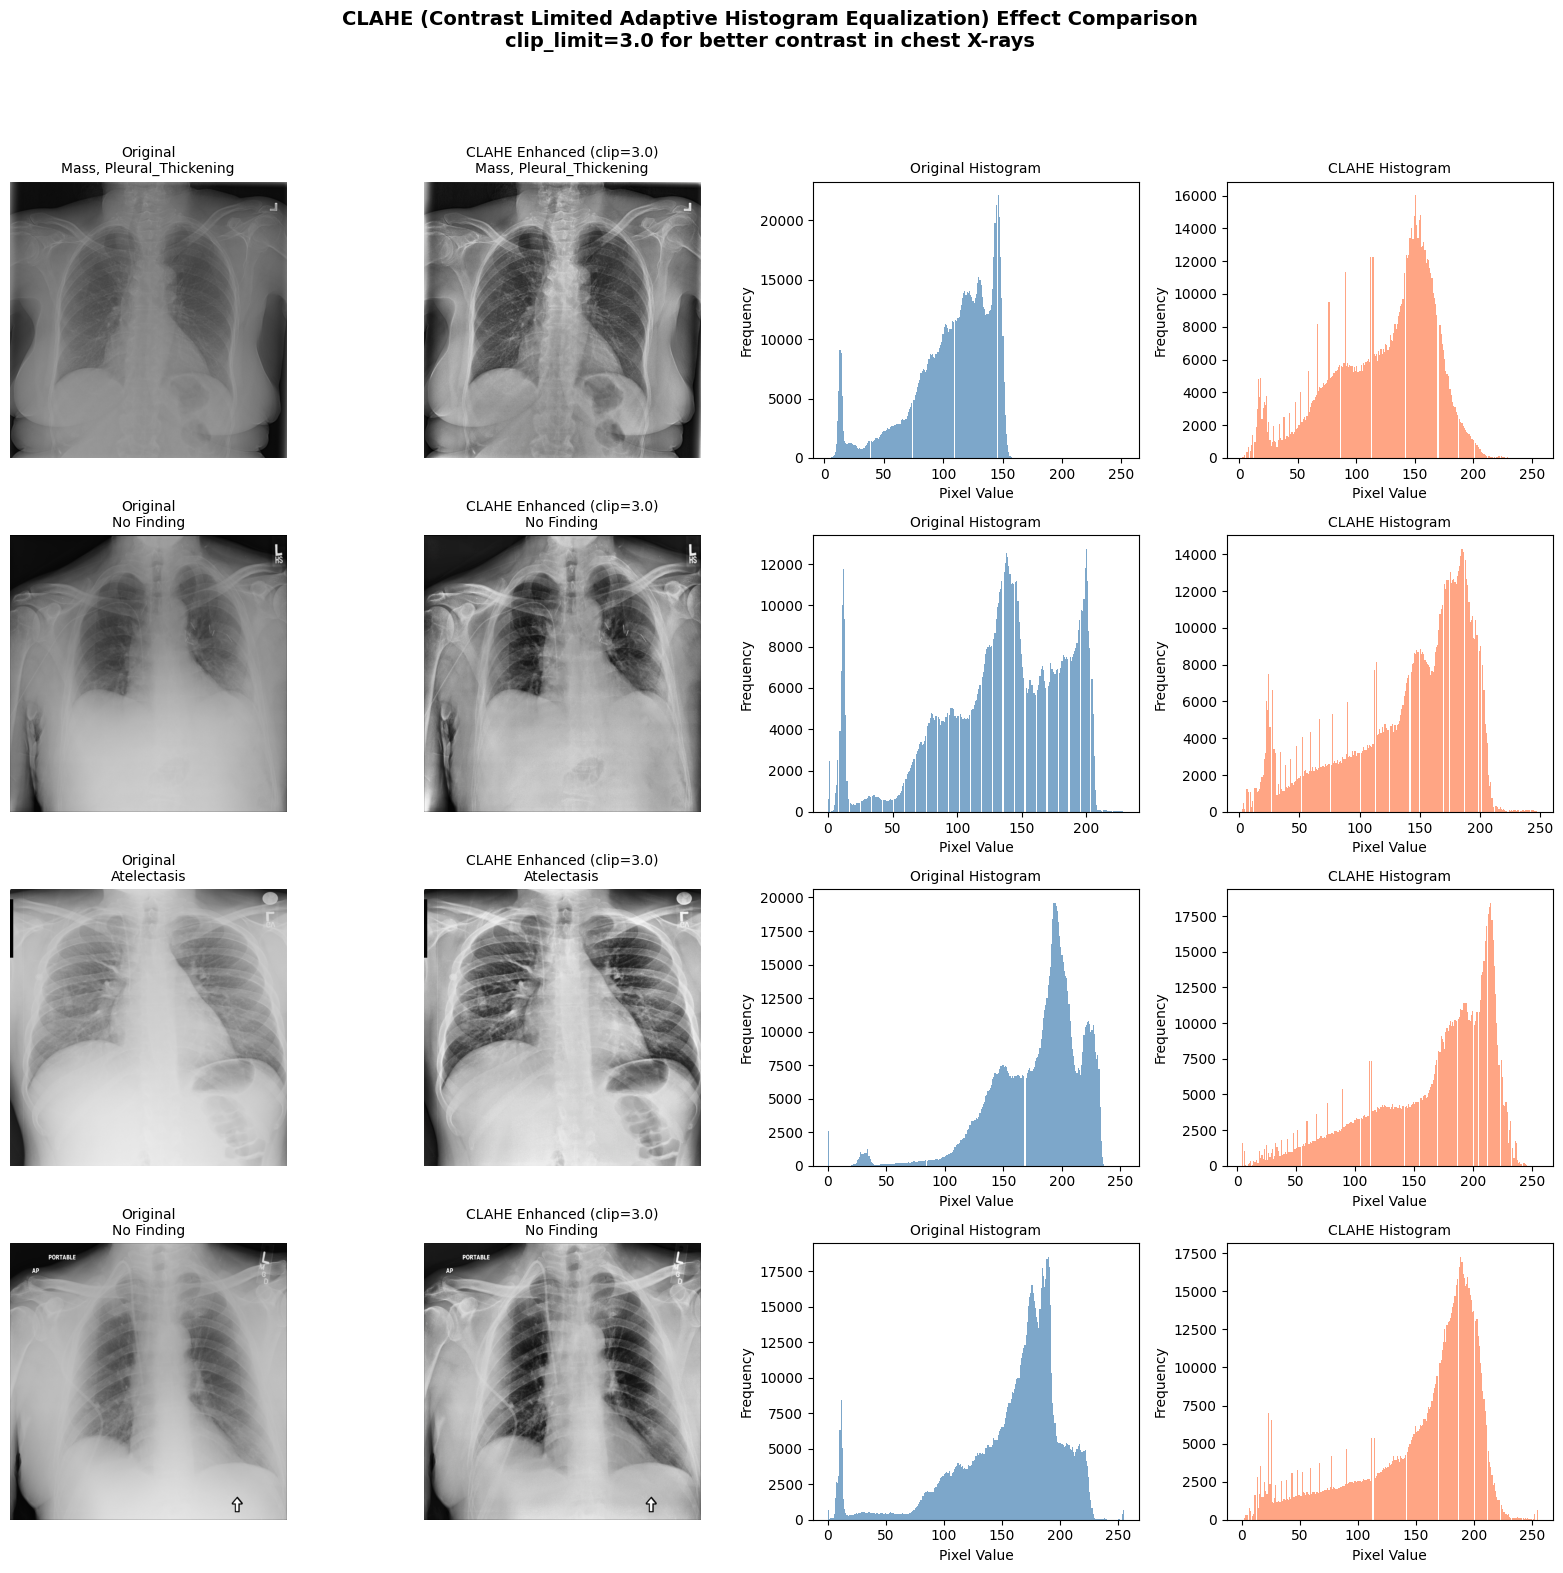


=== Sample from Training Dataset (with CLAHE) ===


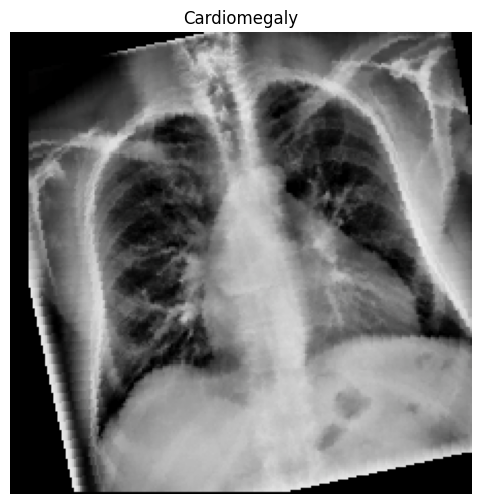


Training Configuration (with CLAHE):
  - Image size: 224x224
  - CLAHE: Enabled (clip_limit=3.0)
  - Augmentation:
      + HorizontalFlip (p=0.5)
      + RandomRotation (±15°)
      + RandomAffine (translate, scale)
      + ColorJitter (brightness, contrast)
      + RandomErasing (p=0.1)
  - Batch size: 32
  - Epochs: 15, Folds: 3
  - Loss: Focal Loss


In [24]:
def visualize_clahe_effect(image_paths, labels_df, disease_cols, n_samples=4):
    clahe_transform = CLAHETransform(clip_limit=3.0, tile_grid_size=(8, 8))  # Updated clip_limit=3.0
    
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))
    
    sample_indices = np.random.choice(len(labels_df), n_samples, replace=False)
    
    for i, idx in enumerate(sample_indices):
        row = labels_df.iloc[idx]
        img_path = image_paths.get(row['Image_index'])
        
        if img_path and os.path.exists(img_path):
            img_original = Image.open(img_path).convert('RGB')
            img_np_original = np.array(img_original)
            
            img_clahe = clahe_transform(img_original)
            img_np_clahe = np.array(img_clahe)
            
            diseases = [d for d in disease_cols if row[d] == 1]
            disease_text = ', '.join(diseases) if diseases else 'No Finding'
            
            # Plot original
            axes[i, 0].imshow(img_np_original)
            axes[i, 0].set_title(f'Original\n{disease_text}', fontsize=10)
            axes[i, 0].axis('off')
            
            # Plot CLAHE enhanced
            axes[i, 1].imshow(img_np_clahe)
            axes[i, 1].set_title(f'CLAHE Enhanced (clip=3.0)\n{disease_text}', fontsize=10)
            axes[i, 1].axis('off')
            
            # Plot histogram of original (grayscale)
            gray_original = cv2.cvtColor(img_np_original, cv2.COLOR_RGB2GRAY)
            axes[i, 2].hist(gray_original.ravel(), bins=256, color='steelblue', alpha=0.7)
            axes[i, 2].set_title('Original Histogram', fontsize=10)
            axes[i, 2].set_xlabel('Pixel Value')
            axes[i, 2].set_ylabel('Frequency')
            
            # Plot histogram of CLAHE enhanced (grayscale)
            gray_clahe = cv2.cvtColor(img_np_clahe, cv2.COLOR_RGB2GRAY)
            axes[i, 3].hist(gray_clahe.ravel(), bins=256, color='coral', alpha=0.7)
            axes[i, 3].set_title('CLAHE Histogram', fontsize=10)
            axes[i, 3].set_xlabel('Pixel Value')
            axes[i, 3].set_ylabel('Frequency')
    
    plt.suptitle('CLAHE (Contrast Limited Adaptive Histogram Equalization) Effect Comparison\nclip_limit=3.0 for better contrast in chest X-rays', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

print('=== CLAHE Preprocessing Visualization (clip_limit=3.0) ===')
visualize_clahe_effect(all_image_paths, train_labels, disease_cols, n_samples=4)

def deprocess(img):
    img = img.permute(1,2,0) #(C, H, W) -> (H, W, C) for plotting matplotlib
    img = img * torch.Tensor([0.229, 0.224, 0.225]) + torch.Tensor([0.485, 0.456, 0.406])
    return img

print('\n=== Sample from Training Dataset (with CLAHE) ===')
image, label = train[0]
class_labels = list(np.where(label==1)[0])
plt.figure(figsize=(6, 6))
plt.imshow(deprocess(image))
plt.title(', '.join([disease_cols[i] for i in class_labels]) if class_labels else 'No Finding')
plt.axis('off')
plt.show()

print(f'\nTraining Configuration (with CLAHE):')
print(f'  - Image size: 224x224')
print(f'  - CLAHE: Enabled (clip_limit=3.0)')
print(f'  - Augmentation:')
print(f'      + HorizontalFlip (p=0.5)')
print(f'      + RandomRotation (±15°)')
print(f'      + RandomAffine (translate, scale)')
print(f'      + ColorJitter (brightness, contrast)')
print(f'      + RandomErasing (p=0.1)')
print(f'  - Batch size: 32')
print(f'  - Epochs: 15, Folds: 3')
print(f'  - Loss: Focal Loss')

In [25]:
# Optimize DataLoader for GPU - Same as DenseNet baseline
NUM_WORKERS = 4  
PIN_MEMORY = torch.cuda.is_available() 

train_loader = DataLoader(train, batch_size=32, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False)
test_loader = DataLoader(test, batch_size=32, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False)

### Model

In [26]:
class Net(nn.Module):
    def __init__(self, num_classes=14, dropout_rate=0.5):
        super(Net, self).__init__()
        self.densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        
        # Unfreeze last 30 parameters for better fine-tuning (same as DenseNet baseline)
        for param in list(self.densenet.parameters())[:-30]:
            param.requires_grad = False
        
        num_features = self.densenet.classifier.in_features 
        self.densenet.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.densenet(x)


model = Net(num_classes=len(disease_cols), dropout_rate=0.5).to(device)
print(f'Model loaded on: {device}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 182MB/s]


Model loaded on: cuda
Total parameters: 7,615,118
Trainable parameters: 1,339,662


### Training

In [27]:
from sklearn.model_selection import GroupKFold
from torch.utils.data import Subset, DataLoader

In [28]:
class FocalLoss(nn.Module):
    """Focal Loss for multi-label classification"""
    def __init__(self, alpha=1, gamma=2, pos_weight=None, label_smoothing=0.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight
        self.label_smoothing = label_smoothing
        
    def forward(self, inputs, targets):
        # Apply label smoothing
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + 0.5 * self.label_smoothing
        
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets, 
            pos_weight=self.pos_weight,
            reduction='none'
        )
        
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        
        return focal_loss.mean()

In [ ]:
# ==================== TRAINING CONFIGURATION (Same as DenseNet baseline) ====================
epochs = 10
n_folds = 2
batch_size = 64
learning_rate = 1e-3
weight_decay = 1e-4

scaler = GradScaler('cuda') if torch.cuda.is_available() else None
use_amp = torch.cuda.is_available()

# Class weights for imbalanced data
freq = train_labels[disease_cols].sum(axis=0).values
total = len(train_labels)
pos_weight = torch.tensor((total - freq) / (freq + 1e-6), dtype=torch.float32, device=device)
print('Class weights (pos_weight):')
for i, col in enumerate(disease_cols):
    print(f'  {col}: {pos_weight[i].item():.2f}')

groups = train_labels['Patient_id'].values
gkf = GroupKFold(n_splits=5)

train_losses = []
val_losses = []
val_aucs = []
best_models = []

print(f'\n=== Training Configuration (with CLAHE) ===')
print(f'Epochs: {epochs}')
print(f'Folds: {n_folds}')
print(f'Batch size: {batch_size}')
print(f'Learning rate: {learning_rate}')
print(f'Weight decay: {weight_decay}')
print(f'CLAHE: Enabled (clip_limit=3.0)')
print(f'Loss: Focal Loss\n')

for fold, (train_idx, val_idx) in enumerate(gkf.split(train_labels, groups=groups)):
    if fold >= n_folds:
        break
        
    print(f'\n{"="*25} Fold {fold + 1}/{n_folds} {"="*25}')
    
    train_subset = Subset(train, train_idx)
    val_subset = Subset(train, val_idx)
    loader_train = DataLoader(train_subset, batch_size=batch_size, shuffle=True, 
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, 
                              persistent_workers=True if NUM_WORKERS > 0 else False)
    loader_val = DataLoader(val_subset, batch_size=batch_size, shuffle=False, 
                            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                            persistent_workers=True if NUM_WORKERS > 0 else False)
    
    print(f'Train size: {len(train_subset)}, Val size: {len(val_subset)}')
    
    model = Net(num_classes=len(disease_cols), dropout_rate=0.5).to(device) 
    
    # Use Focal Loss (same as DenseNet baseline)
    criterion = FocalLoss(alpha=1, gamma=2, pos_weight=pos_weight, label_smoothing=0.0)
    
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # Cosine Annealing scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    valid_loss_min = np.inf
    best_val_auc = 0.0
    fold_train_losses = []
    fold_val_losses = []
    fold_val_aucs = []
    patience_counter = 0
    early_stop_patience = 5
    
    for epoch in range(epochs):
        current_lr = optimizer.param_groups[0]['lr']
        
        # ========== Training ==========
        model.train()
        train_loss = 0.0
        
        train_pbar = tqdm(loader_train, desc=f'Fold {fold+1} | Epoch {epoch+1}/{epochs} [Train]')
        for images, labels_batch in train_pbar:
            images = images.to(device, non_blocking=True)
            labels_batch = labels_batch.float().to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            
            if use_amp:
                with autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels_batch)
                
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            train_loss += loss.item()
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.2e}'})
        
        scheduler.step()
        
        avg_train_loss = train_loss / len(loader_train)
        fold_train_losses.append(avg_train_loss)
        
        # ========== Validation ==========
        model.eval()
        valid_loss = 0.0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            val_pbar = tqdm(loader_val, desc=f'Fold {fold+1} | Epoch {epoch+1}/{epochs} [Val]')
            for images, labels_batch in val_pbar:
                images = images.to(device, non_blocking=True)
                labels_batch = labels_batch.float().to(device, non_blocking=True)
                
                if use_amp:
                    with autocast('cuda'):
                        outputs = model(images)
                        loss = criterion(outputs, labels_batch)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels_batch)
                
                valid_loss += loss.item()
                
                preds = torch.sigmoid(outputs)
                all_preds.append(preds.cpu())
                all_labels.append(labels_batch.cpu())
                
                val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_valid_loss = valid_loss / len(loader_val)
        fold_val_losses.append(avg_valid_loss)
        
        all_preds = torch.cat(all_preds).numpy()
        all_labels = torch.cat(all_labels).numpy()
        val_acc = ((all_preds >= 0.5) == all_labels).mean() * 100
        
        # Calculate mean AUC-ROC
        try:
            from sklearn.metrics import roc_auc_score
            val_auc = roc_auc_score(all_labels, all_preds, average='macro') * 100
        except:
            val_auc = 0.0
        fold_val_aucs.append(val_auc)
        
        # Save best model based on AUC
        if val_auc > best_val_auc:
            print(f'=> Val AUC improved ({best_val_auc:.2f}% -> {val_auc:.2f}%). Saving model...')
            torch.save({
                'fold': fold,
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'valid_loss': avg_valid_loss,
                'val_auc': val_auc,
                'val_accuracy': val_acc
            }, f'model_clahe_fold{fold+1}.pt')
            best_val_auc = val_auc
            valid_loss_min = avg_valid_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        print(f'Epoch {epoch+1}: Train Loss = {avg_train_loss:.6f} | Val Loss = {avg_valid_loss:.6f} | Val Acc = {val_acc:.2f}% | Val AUC = {val_auc:.2f}% | LR = {current_lr:.2e}')
        
        if patience_counter >= early_stop_patience:
            print(f'Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience} epochs)')
            break
    
    train_losses.append(fold_train_losses)
    val_losses.append(fold_val_losses)
    val_aucs.append(fold_val_aucs)
    best_models.append(f'model_clahe_fold{fold+1}.pt')

print('\nTraining completed!')
print(f'Best models saved: {best_models}')
print(f'Best validation AUC: {best_val_auc:.2f}%')

Class weights (pos_weight):
  Atelectasis: 9.45
  Cardiomegaly: 49.69
  Consolidation: 29.34
  Edema: 61.79
  Effusion: 8.99
  Emphysema: 59.80
  Fibrosis: 68.16
  Hernia: 612.65
  Infiltration: 5.28
  Mass: 20.45
  Nodule: 17.38
  Pleural_Thickening: 37.59
  Pneumonia: 97.77
  Pneumothorax: 31.81

=== Training Configuration (with CLAHE) ===
Epochs: 10
Folds: 2
Batch size: 64
Learning rate: 0.001
Weight decay: 0.0001
CLAHE: Enabled (clip_limit=3.0)
Loss: Focal Loss


========================= Fold 1/2 =========================
Train size: 69219, Val size: 17305


Fold 1 | Epoch 1/10 [Train]: 100%|██████████| 1082/1082 [25:09<00:00,  1.40s/it, loss=0.8283, lr=1.00e-03]
Fold 1 | Epoch 1/10 [Val]: 100%|██████████| 271/271 [06:21<00:00,  1.41s/it, loss=1.0373]


=> Val AUC improved (0.00% -> 74.62%). Saving model...
Epoch 1: Train Loss = 0.768622 | Val Loss = 0.694195 | Val Acc = 49.72% | Val AUC = 74.62% | LR = 1.00e-03


Fold 1 | Epoch 2/10 [Train]: 100%|██████████| 1082/1082 [24:26<00:00,  1.36s/it, loss=0.6700, lr=9.76e-04]
Fold 1 | Epoch 2/10 [Val]: 100%|██████████| 271/271 [06:05<00:00,  1.35s/it, loss=1.0900]


=> Val AUC improved (74.62% -> 75.75%). Saving model...
Epoch 2: Train Loss = 0.702507 | Val Loss = 0.679490 | Val Acc = 53.95% | Val AUC = 75.75% | LR = 9.76e-04


...

=> Val AUC improved (77.88% -> 78.24%). Saving model...
Epoch 8: Train Loss = 0.616075 | Val Loss = 0.673266 | Val Acc = 59.30% | Val AUC = 78.24% | LR = 2.07e-04


Fold 2 | Epoch 9/10 [Train]: 100%|██████████| 1082/1082 [24:12<00:00,  1.34s/it, loss=1.1178, lr=9.64e-05]
Fold 2 | Epoch 9/10 [Val]: 100%|██████████| 271/271 [06:12<00:00,  1.37s/it, loss=0.7056]


=> Val AUC improved (78.24% -> 78.39%). Saving model...
Epoch 9: Train Loss = 0.607908 | Val Loss = 0.670617 | Val Acc = 58.66% | Val AUC = 78.39% | LR = 9.64e-05


Fold 2 | Epoch 10/10 [Train]: 100%|██████████| 1082/1082 [23:44<00:00,  1.32s/it, loss=0.4759, lr=2.54e-05]
Fold 2 | Epoch 10/10 [Val]: 100%|██████████| 271/271 [06:14<00:00,  1.38s/it, loss=0.6947]

Epoch 10: Train Loss = 0.603327 | Val Loss = 0.691687 | Val Acc = 59.28% | Val AUC = 78.11% | LR = 2.54e-05

Training completed!
Best models saved: ['model_clahe_fold1.pt', 'model_clahe_fold2.pt']
Best validation AUC: 78.39%


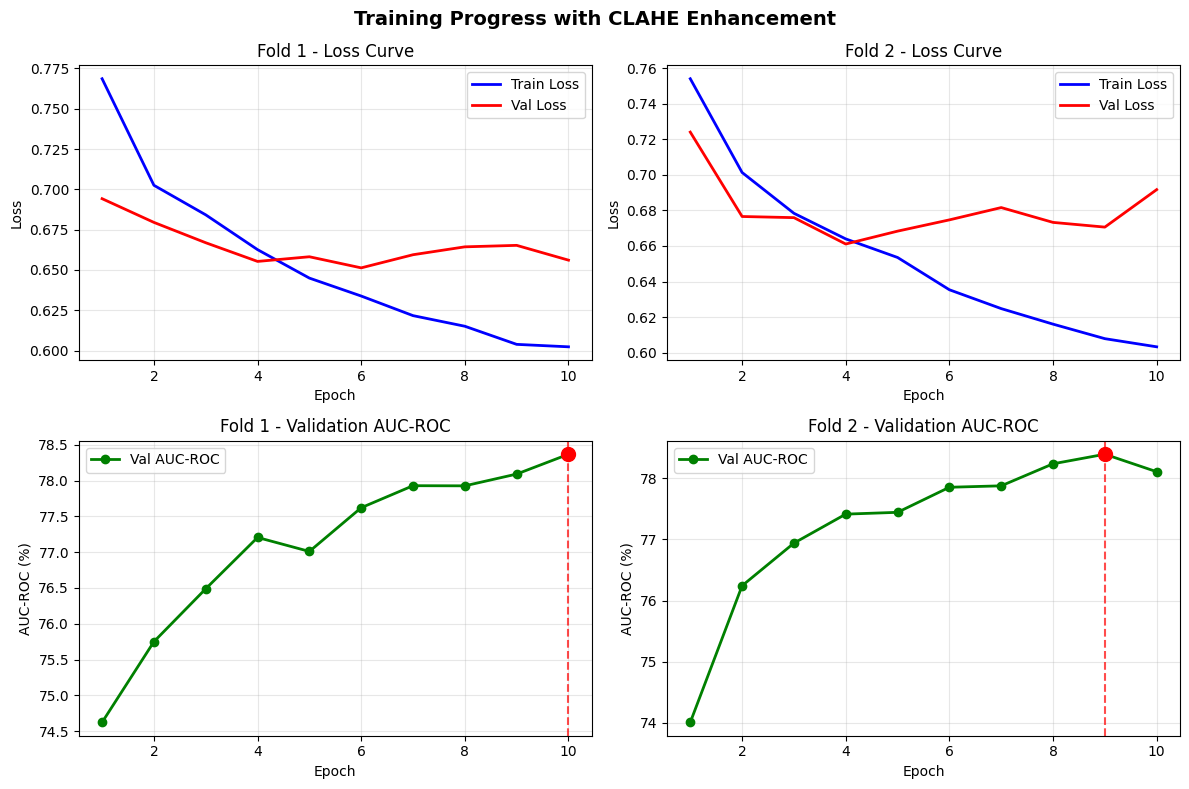

Best validation AUC across folds: 78.39%


In [30]:
fig, axes = plt.subplots(2, len(train_losses), figsize=(6*len(train_losses), 8))
if len(train_losses) == 1:
    axes = axes.reshape(2, 1)

for i, (train_loss, val_loss, val_auc) in enumerate(zip(train_losses, val_losses, val_aucs)):
    # Loss curve
    axes[0, i].plot(range(1, len(train_loss)+1), train_loss, 'b-', label='Train Loss', linewidth=2)
    axes[0, i].plot(range(1, len(val_loss)+1), val_loss, 'r-', label='Val Loss', linewidth=2)
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].set_title(f'Fold {i+1} - Loss Curve')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)
    
    # AUC curve
    axes[1, i].plot(range(1, len(val_auc)+1), val_auc, 'g-', label='Val AUC-ROC', linewidth=2, marker='o')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('AUC-ROC (%)')
    axes[1, i].set_title(f'Fold {i+1} - Validation AUC-ROC')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)
    
    # Mark best epoch
    best_epoch = np.argmax(val_auc) + 1
    best_auc = max(val_auc)
    axes[1, i].axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_auc:.2f}%')
    axes[1, i].scatter([best_epoch], [best_auc], color='red', s=100, zorder=5)

plt.suptitle('Training Progress with CLAHE Enhancement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best validation AUC across folds: {max([max(auc) for auc in val_aucs]):.2f}%')

In [31]:
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, 
    precision_score, recall_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

def evaluate_model(dataloader, model, disease_cols, threshold=0.5, dataset_name='Dataset'):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f'Evaluating {dataset_name}'):
            images = images.to(device, non_blocking=True)
            
            if use_amp:
                with autocast('cuda'):
                    outputs = model(images)
            else:
                outputs = model(images)
            
            preds = torch.sigmoid(outputs)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # Per-class comprehensive metrics
    results = []
    for i, col in enumerate(disease_cols):
        pred_binary = (all_preds[:, i] >= threshold).astype(int)
        true_labels = all_labels[:, i].astype(int)
        
        tp = ((pred_binary == 1) & (true_labels == 1)).sum()
        tn = ((pred_binary == 0) & (true_labels == 0)).sum()
        fp = ((pred_binary == 1) & (true_labels == 0)).sum()
        fn = ((pred_binary == 0) & (true_labels == 1)).sum()
        
        accuracy = (pred_binary == true_labels).mean() * 100
        
        try:
            auc = roc_auc_score(true_labels, all_preds[:, i]) * 100
        except:
            auc = 0.0
        
        precision = precision_score(true_labels, pred_binary, zero_division=0) * 100
        recall = recall_score(true_labels, pred_binary, zero_division=0) * 100
        f1 = f1_score(true_labels, pred_binary, zero_division=0) * 100
        
        results.append({
            'Disease': col,
            'Accuracy': round(accuracy, 2),
            'AUC-ROC': round(auc, 2),
            'Precision': round(precision, 2),
            'Recall': round(recall, 2),
            'F1-Score': round(f1, 2),
            'TP': int(tp),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn),
            'Total_Positive': int(true_labels.sum()),
            'Predicted_Positive': int(pred_binary.sum())
        })
    
    df_results = pd.DataFrame(results)
    
    # Overall metrics
    print(f'\n{'='*60}')
    print(f'{dataset_name.upper()} EVALUATION RESULTS')
    print(f'{'='*60}')
    print(f'Overall Label Accuracy: {((all_preds >= threshold) == all_labels).mean() * 100:.2f}%')
    print(f'Mean AUC-ROC: {df_results['AUC-ROC'].mean():.2f}%')
    print(f'Mean F1-Score: {df_results['F1-Score'].mean():.2f}%')
    print(f'{'='*60}\n')
    
    return df_results, all_preds, all_labels


def plot_roc_curves(all_labels, all_preds, disease_cols, title_suffix=''):
    fig, axes = plt.subplots(4, 4, figsize=(16, 14))
    axes = axes.flatten()
    
    for i, col in enumerate(disease_cols):
        ax = axes[i]
        
        try:
            fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            ax.plot(fpr, tpr, 'b-', label=f'AUC = {auc:.3f}')
            ax.plot([0, 1], [0, 1], 'r--', label='Random')
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.set_title(f'{col}', fontweight='bold')
            ax.legend(loc='lower right')
            ax.grid(True, alpha=0.3)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center')
            ax.set_title(f'{col}', fontweight='bold')
    
    for j in range(len(disease_cols), len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f'ROC Curves{title_suffix}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_precision_recall_curves(all_labels, all_preds, disease_cols, title_suffix=''):
    fig, axes = plt.subplots(4, 4, figsize=(16, 14))
    axes = axes.flatten()
    
    for i, col in enumerate(disease_cols):
        ax = axes[i]
        
        try:
            precision, recall, _ = precision_recall_curve(all_labels[:, i], all_preds[:, i])
            ap = average_precision_score(all_labels[:, i], all_preds[:, i])
            ax.plot(recall, precision, 'b-', label=f'AP = {ap:.3f}')
            ax.set_xlabel('Recall')
            ax.set_ylabel('Precision')
            ax.set_title(f'{col}', fontweight='bold')
            ax.legend(loc='lower left')
            ax.grid(True, alpha=0.3)
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center')
            ax.set_title(f'{col}', fontweight='bold')
    
    for j in range(len(disease_cols), len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f'Precision-Recall Curves{title_suffix}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def class_accuracy(dataloader, model):
    per_class_accuracy = [0 for i in range(len(disease_cols))]

    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            if use_amp:
                with autocast('cuda'):
                    ps = model(images)
            else:
                ps = model(images)
            
            ps = (torch.sigmoid(ps) >= 0.5).float() 

            for i in range(ps.shape[1]):
                x1 = ps[:,i:i+1]
                x2 = labels[:,i:i+1]
                per_class_accuracy[i] += int((x1 == x2).sum())

        per_class_accuracy = [(i/len(dataloader.dataset))*100.0 for i in per_class_accuracy]

    return per_class_accuracy     

def get_acc_data(class_names, acc_list):
    df = pd.DataFrame(list(zip(class_names, acc_list)), columns=['Labels', 'Acc']) 
    return df

TRAIN DATASET EVALUATION (CLAHE Enhanced)
Loaded CLAHE model from fold 1, epoch 10
Best validation loss: 0.656063
Best validation AUC: 78.37%


Evaluating Train: 100%|██████████| 2704/2704 [30:25<00:00,  1.48it/s]



TRAIN EVALUATION RESULTS
Overall Label Accuracy: 59.98%
Mean AUC-ROC: 81.62%
Mean F1-Score: 14.04%


--- Detailed Train Results by Disease ---


,Disease,Accuracy,AUC-ROC,Precision,Recall,F1-Score,TP,TN,FP,FN,Total_Positive,Predicted_Positive
0,Atelectasis,53.64,77.81,15.64,87.50,26.54,7245,39163,39081,1035,8280,46326
1,Cardiomegaly,67.05,87.90,5.14,89.87,9.72,1534,56481,28336,173,1707,29870
2,Consolidation,56.29,79.42,6.21,86.89,11.59,2478,46228,37444,374,2852,39922
3,Edema,71.51,91.49,4.98,93.47,9.46,1288,60584,24562,90,1378,25850
4,Effusion,67.46,86.66,22.15,89.55,35.52,7754,50614,27251,905,8659,35005
5,Emphysema,71.14,89.63,4.80,87.84,9.10,1250,60303,24798,173,1423,26048
6,Fibrosis,57.32,80.61,2.85,86.09,5.51,1077,48519,36754,174,1251,37831
7,Hernia,95.69,94.69,2.77,74.47,5.34,105,82694,3689,36,141,3794
8,Infiltration,29.67,67.93,17.88,95.07,30.10,13102,12573,60169,680,13782,73271
9,Mass,56.81,77.94,8.26,81.73,15.00,3297,45855,36635,737,4034,39932



--- ROC Curves (Train Set) ---


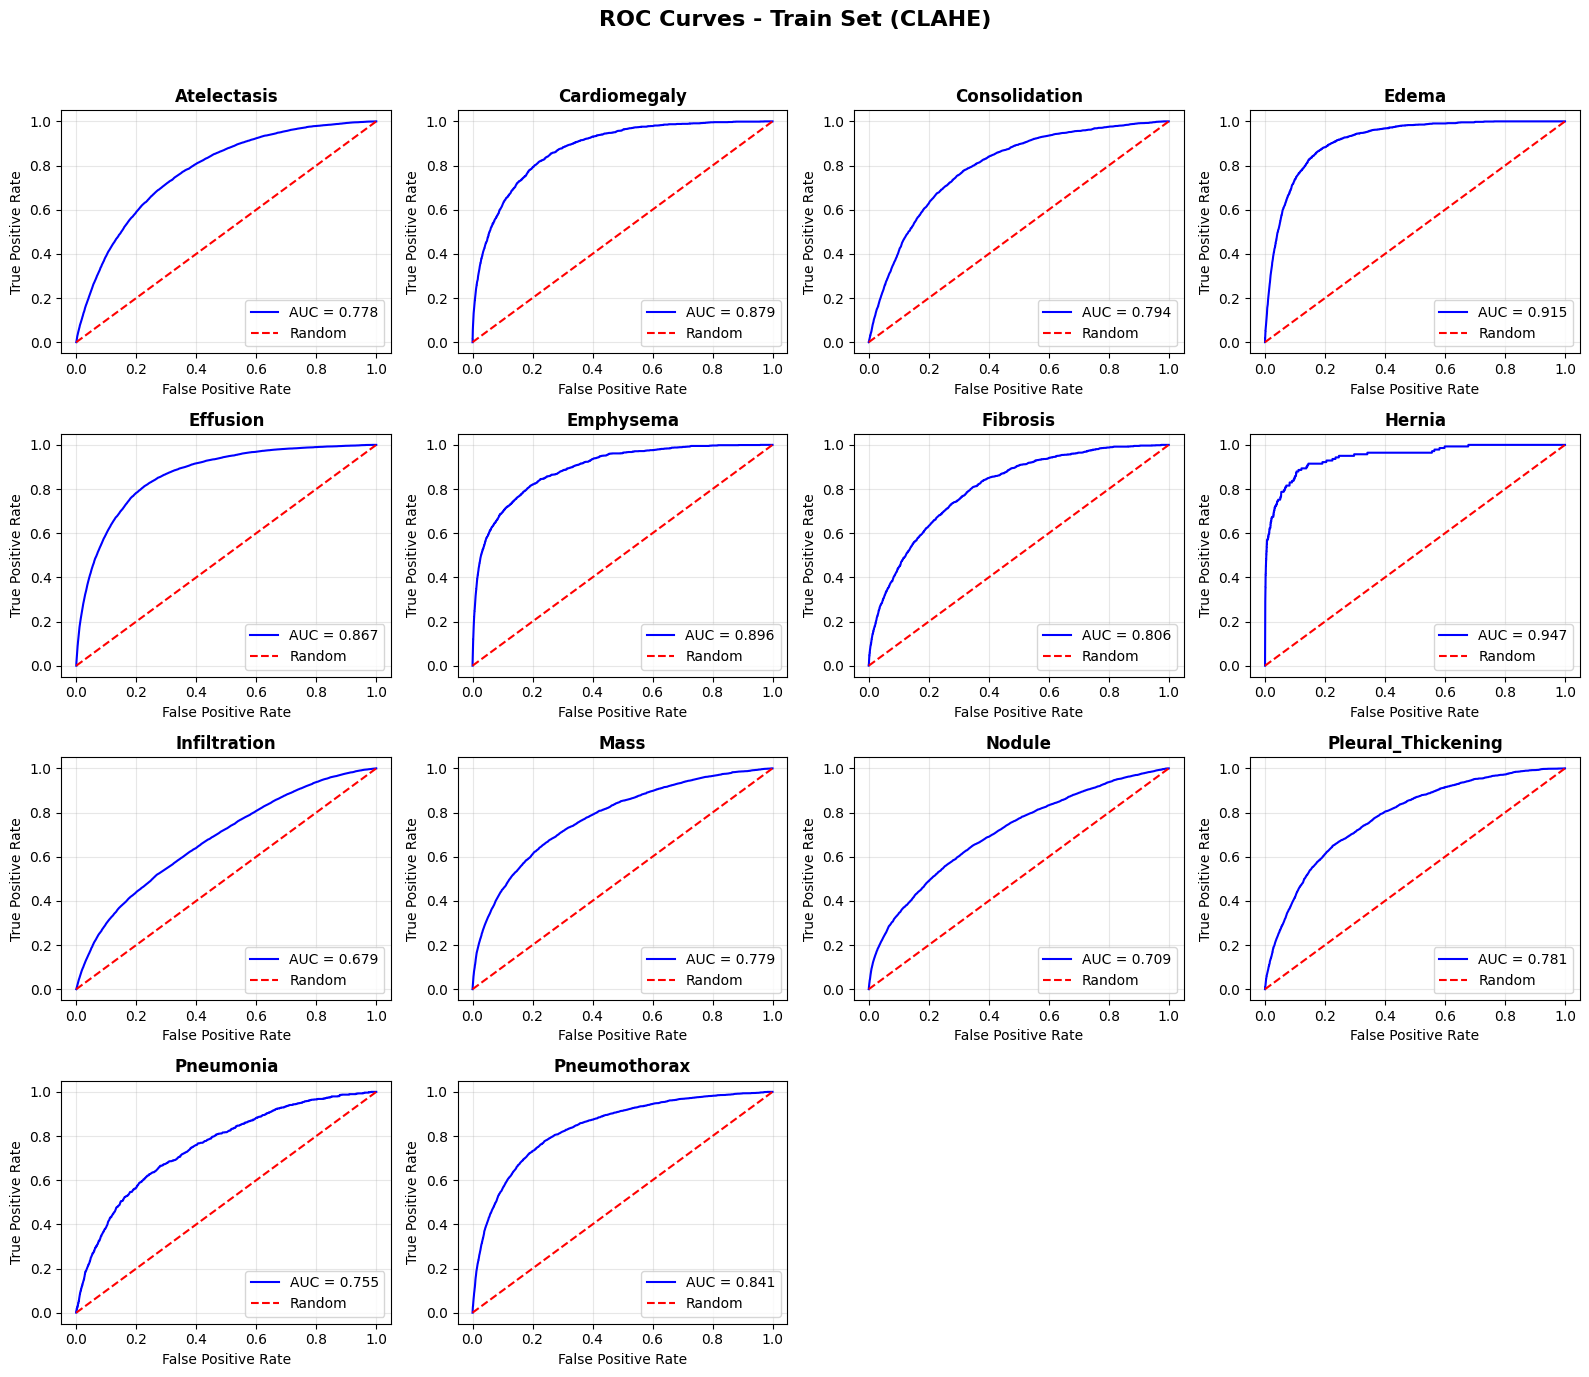


--- Precision-Recall Curves (Train Set) ---


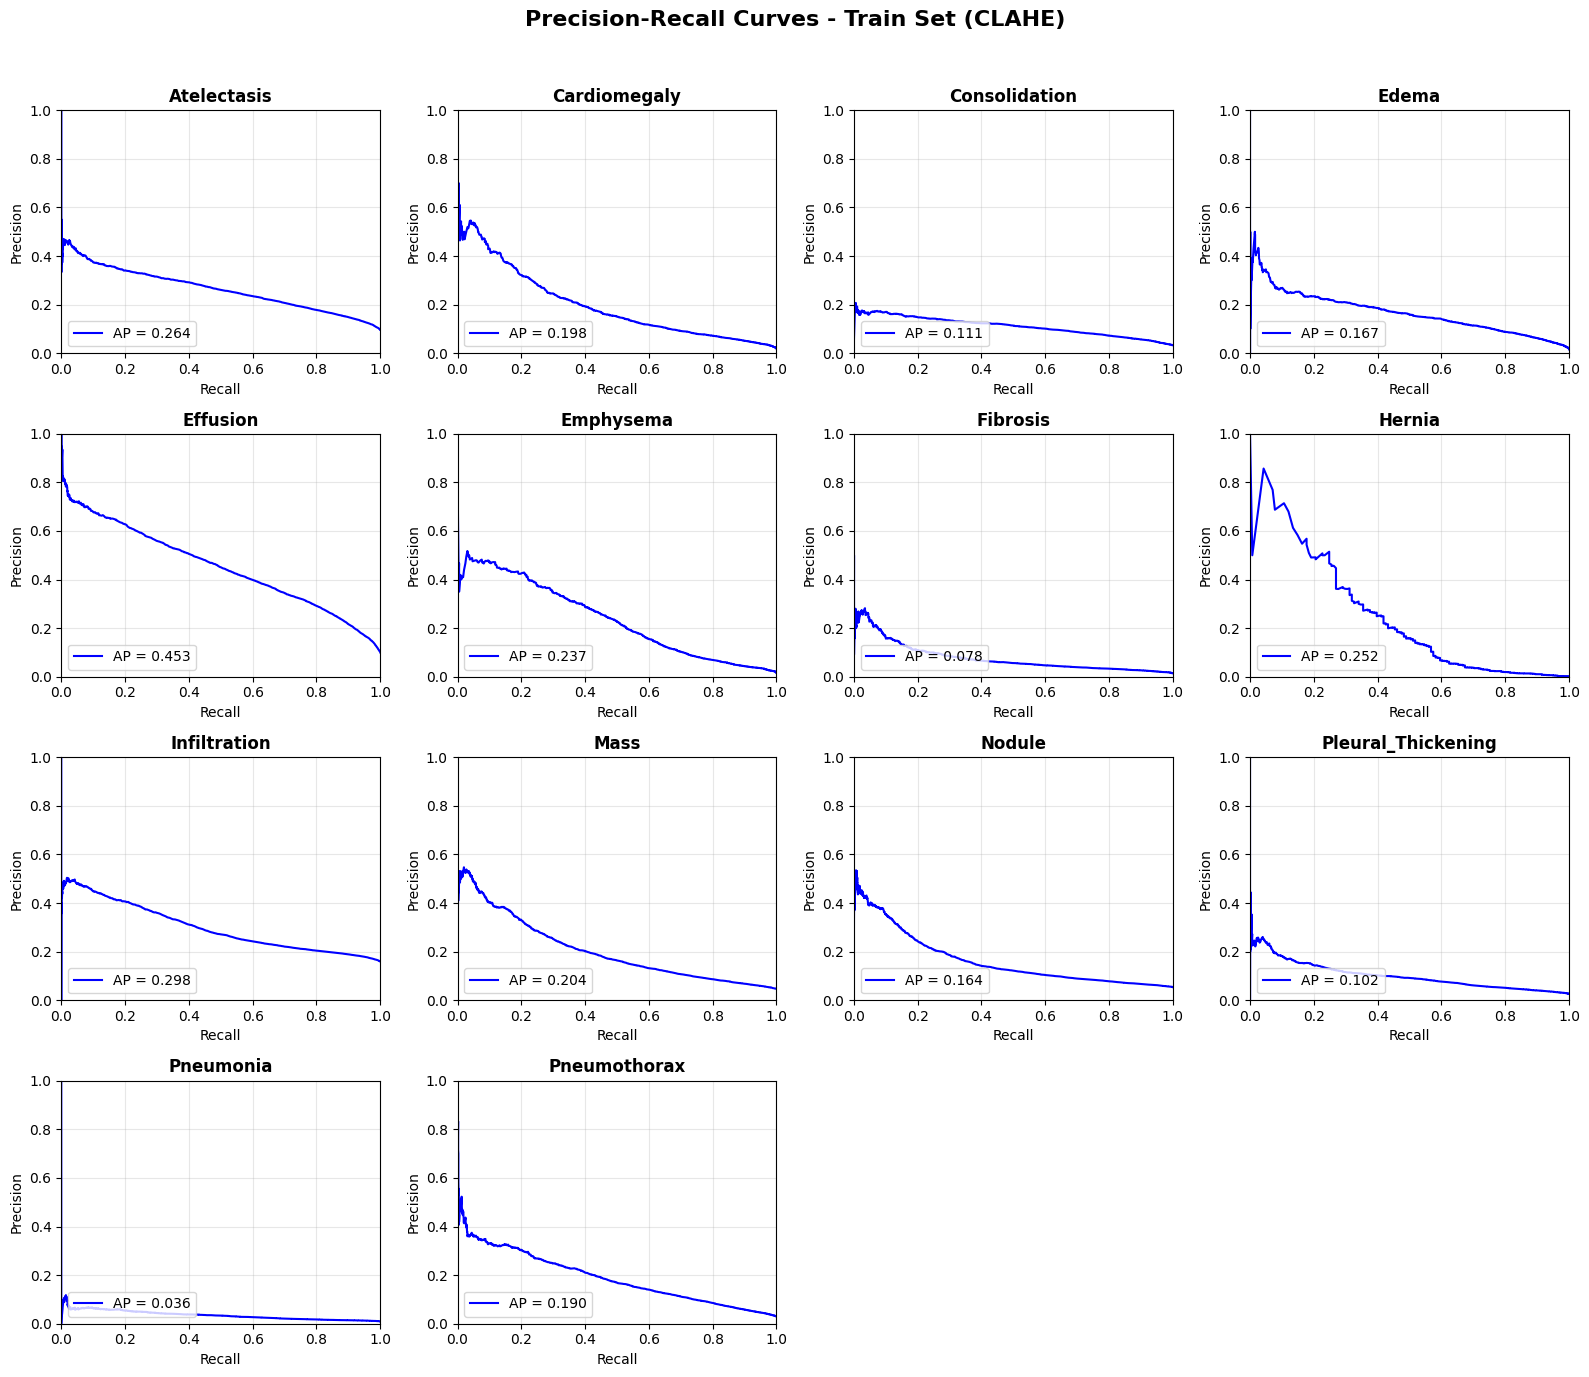

In [32]:
# TRAIN DATASET EVALUATION  
print('='*60)
print('TRAIN DATASET EVALUATION (CLAHE Enhanced)')
print('='*60)

checkpoint = torch.load('model_clahe_fold1.pt', weights_only=False, map_location=device)
model = Net(num_classes=len(disease_cols)).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f'Loaded CLAHE model from fold 1, epoch {checkpoint["epoch"]+1}')
print(f'Best validation loss: {checkpoint["valid_loss"]:.6f}')
print(f'Best validation AUC: {checkpoint["val_auc"]:.2f}%')

train_results, train_preds, train_true = evaluate_model(
    train_loader, model, disease_cols, threshold=0.5, dataset_name='Train'
)

print('\n--- Detailed Train Results by Disease ---')
display(train_results)

print('\n--- ROC Curves (Train Set) ---')
plot_roc_curves(train_true, train_preds, disease_cols, title_suffix=' - Train Set (CLAHE)')

print('\n--- Precision-Recall Curves (Train Set) ---')
plot_precision_recall_curves(train_true, train_preds, disease_cols, title_suffix=' - Train Set (CLAHE)')

TEST DATASET COMPREHENSIVE EVALUATION (CLAHE Enhanced)


Evaluating Test: 100%|██████████| 800/800 [09:00<00:00,  1.48it/s]



TEST EVALUATION RESULTS
Overall Label Accuracy: 49.81%
Mean AUC-ROC: 76.76%
Mean F1-Score: 18.98%


--- Detailed Test Results by Disease ---


,Disease,Accuracy,AUC-ROC,Precision,Recall,F1-Score,TP,TN,FP,FN,Total_Positive,Predicted_Positive
0,Atelectasis,41.26,72.18,16.74,90.18,28.23,2957,7605,14712,322,3279,17669
1,Cardiomegaly,60.37,82.02,8.39,85.59,15.28,915,14538,9989,154,1069,10904
2,Consolidation,29.48,70.97,8.80,95.48,16.11,1733,5812,17969,82,1815,19702
3,Edema,45.10,82.01,5.91,95.14,11.13,880,10664,14007,45,925,14887
4,Effusion,46.86,78.37,24.84,94.80,39.37,4416,7579,13359,242,4658,17775
5,Emphysema,69.94,86.58,11.15,86.64,19.75,947,16955,7548,146,1093,8495
6,Fibrosis,63.93,79.14,3.63,79.08,6.94,344,16020,9141,91,435,9485
7,Hernia,96.32,89.10,4.66,51.16,8.54,44,24609,901,42,86,945
8,Infiltration,28.20,69.16,24.70,97.99,39.46,5989,1228,18256,123,6112,24245
9,Mass,43.82,71.66,9.50,84.73,17.08,1481,9735,14113,267,1748,15594



--- ROC Curves (Test Set) ---


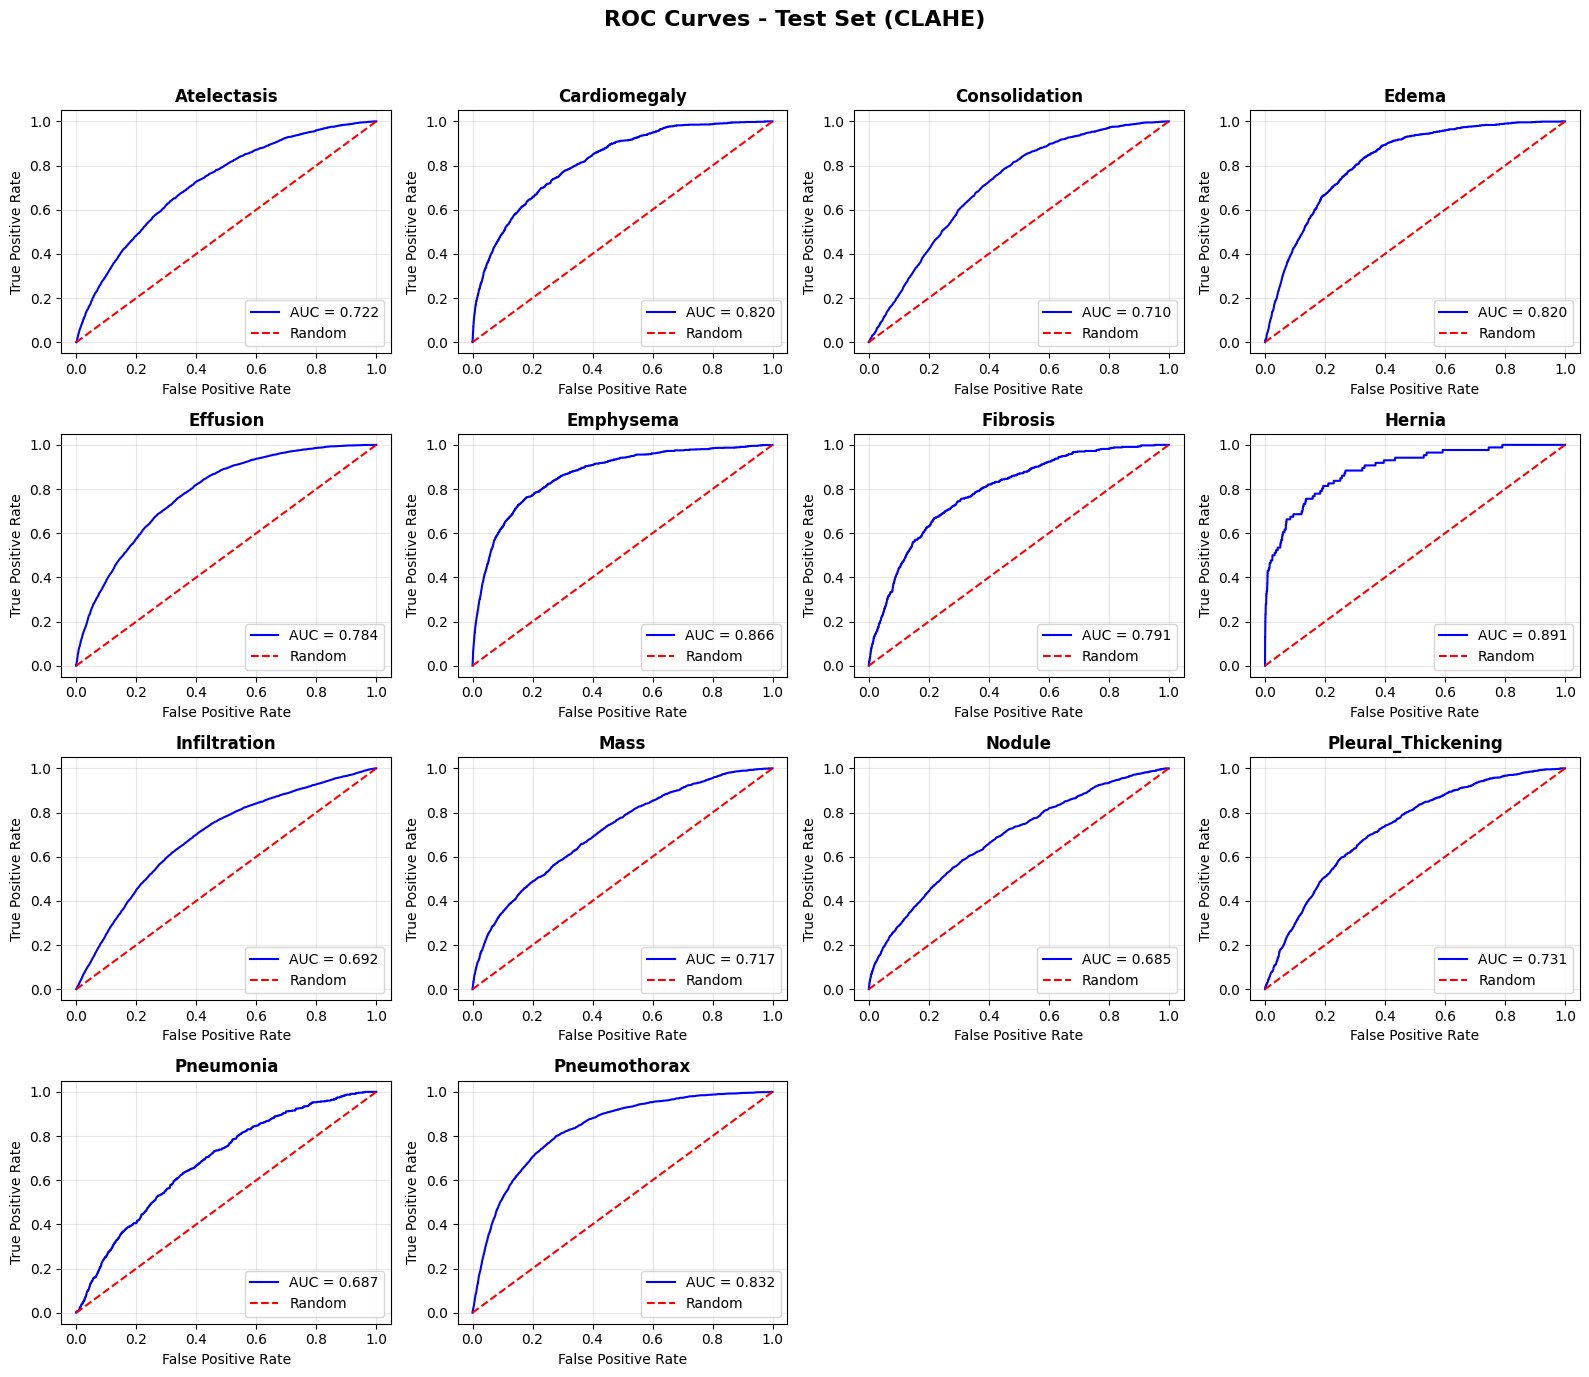


--- Precision-Recall Curves (Test Set) ---


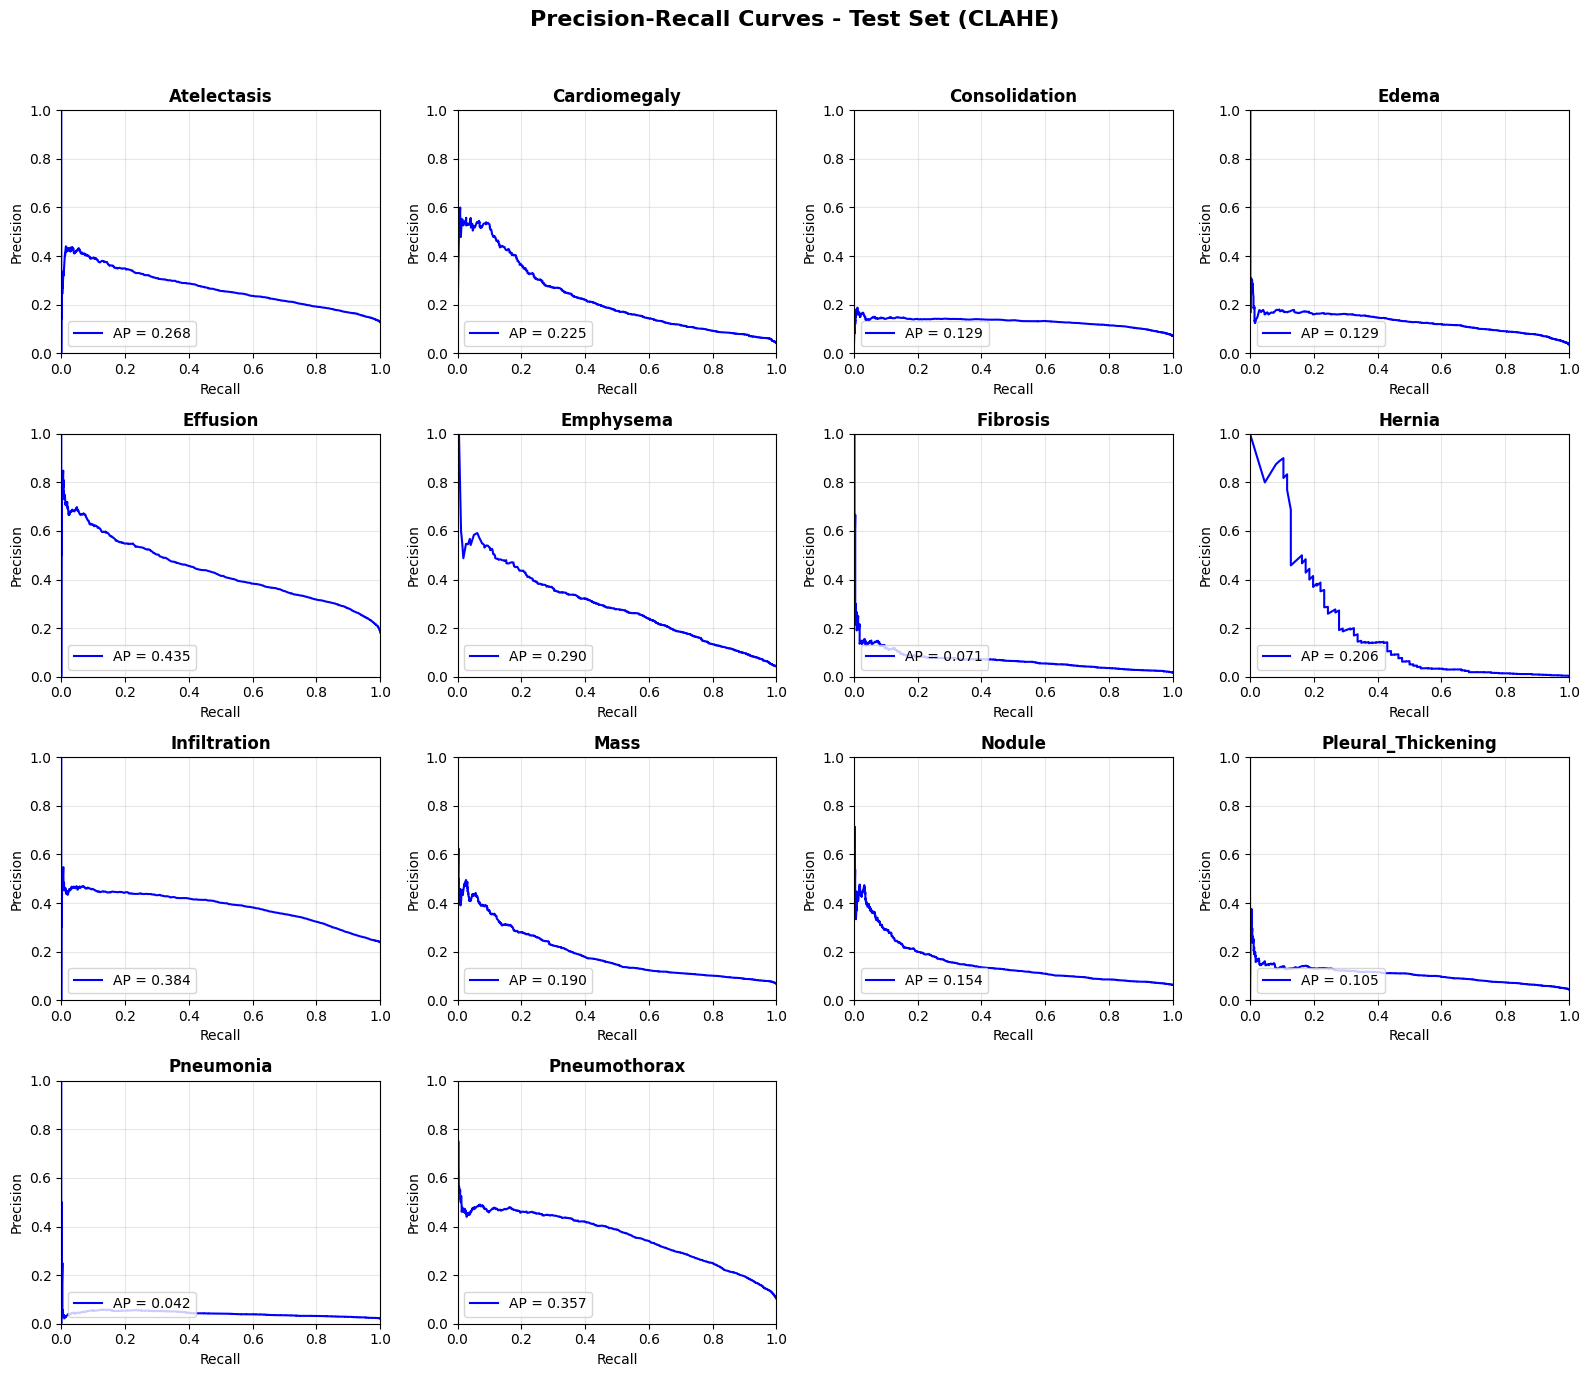


--- Class Accuracy (Test Set) ---


,Labels,Acc
0,Atelectasis,41.264260
1,Cardiomegaly,60.372714
2,Consolidation,29.477262
3,Edema,45.100797
4,Effusion,46.862791
5,Emphysema,69.940616
6,Fibrosis,63.931864
7,Hernia,96.315831
8,Infiltration,28.195812
9,Mass,43.819347



SUMMARY
Mean AUC-ROC (Test): 76.76%
Mean F1-Score (Test): 18.98%
Mean Precision (Test): 11.05%
Mean Recall (Test): 86.72%


In [33]:
# TEST DATASET COMPREHENSIVE EVALUATION
print('='*60)
print('TEST DATASET COMPREHENSIVE EVALUATION (CLAHE Enhanced)')
print('='*60)

test_results, test_preds, test_true = evaluate_model(
    test_loader, model, disease_cols, threshold=0.5, dataset_name='Test'
)

print('\n--- Detailed Test Results by Disease ---')
display(test_results)

print('\n--- ROC Curves (Test Set) ---')
plot_roc_curves(test_true, test_preds, disease_cols, title_suffix=' - Test Set (CLAHE)')

print('\n--- Precision-Recall Curves (Test Set) ---')
plot_precision_recall_curves(test_true, test_preds, disease_cols, title_suffix=' - Test Set (CLAHE)')

print('\n--- Class Accuracy (Test Set) ---')
acc_list = class_accuracy(test_loader, model)
acc_df = get_acc_data(disease_cols, acc_list)
display(acc_df)

# Summary comparison
print('\n' + '='*60)
print('SUMMARY')
print('='*60)
print(f'Mean AUC-ROC (Test): {test_results["AUC-ROC"].mean():.2f}%')
print(f'Mean F1-Score (Test): {test_results["F1-Score"].mean():.2f}%')
print(f'Mean Precision (Test): {test_results["Precision"].mean():.2f}%')
print(f'Mean Recall (Test): {test_results["Recall"].mean():.2f}%')
print('='*60)